In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

%matplotlib inline
sns.set(style='whitegrid')

current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)
train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}")

Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)


In [ ]:
# Danh sách các cột sử dụng để huấn luyện
features_to_keep = ['dien_tich_log', 'phong_tam', 'so_tang', 'quan', 'thanh_pho', 'phap_ly']

# 2. Tách X và y
X_train_raw = train_df[features_to_keep]
y_train = train_df['gia_log']

X_test_raw = test_df[features_to_keep]
y_test_original = test_df['gia'] # Dùng giá gốc để tính MAE, RMSE

# Mã hóa One-Hot Encoding
X_train = pd.get_dummies(X_train_raw, columns=['quan', 'thanh_pho', 'phap_ly'], drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=['quan', 'thanh_pho', 'phap_ly'], drop_first=True)

# Đồng bộ hóa các cột giữa tập Train và Test
# Nếu tập Test thiếu một số quận xuất hiện ở tập Train, ta điền giá trị 0
X_test = X_test.reindex(columns = X_train.columns, fill_value=0)

print(f"Số lượng đặc trưng sau khi mã hóa: {X_train.shape[1]}")
X_train.head()

Số lượng đặc trưng sau khi mã hóa: 37


,dien_tich_log,phong_tam,so_tang,quan_Huyện Thanh Trì,quan_Quận 1,quan_Quận 10,quan_Quận 11,quan_Quận 12,quan_Quận 2,quan_Quận 3,...,quan_Quận Nam Từ Liêm,quan_Quận Phú Nhuận,quan_Quận Thanh Xuân,quan_Quận Tân Bình,quan_Quận Tân Phú,quan_Quận Tây Hồ,quan_Quận Đống Đa,quan_Quận/Huyện khác,thanh_pho_TP.HCM,phap_ly_Đã có sổ
0,4.653960,2,6,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,4.330733,2,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
2,4.262680,6,7,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4.394449,8,8,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
4,4.268298,5,3,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True


In [3]:
# Khởi tạo mô hình OLS
model = LinearRegression()

# Huấn luyện trên thang đo Log
model.fit(X_train, y_train)

print("Huấn luyện mô hình hoàn tất!")
print(f"Hệ số chặn (Intercept): {model.intercept_:.4f}")

Huấn luyện mô hình hoàn tất!
Hệ số chặn (Intercept): -1.4614


In [ ]:
y_pred_log = model.predict(X_test)

# Chuyển ngược về đơn vị gốc (Tỷ VNĐ)
y_pred_original = np.expm1(y_pred_log)

# Tính toán 4 chỉ số Metrics
r2 = r2_score(test_df['gia_log'], y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original) 
rmse = np.sqrt(mse)

# 4. Hiển thị bảng kết quả chuyên nghiệp
results = pd.DataFrame({
    'Metric': [
        'R-squared (R2)', 
        'Mean Absolute Error (MAE)', 
        'Mean Squared Error (MSE)', 
        'Root Mean Squared Error (RMSE)'
    ],
    'Value': [
        f"{r2:.4f}", 
        f"{mae:.4f} Tỷ VNĐ", 
        f"{mse:.4f} Tỷ^2", 
        f"{rmse:.4f} Tỷ VNĐ"
    ]
})

print("--- HIỆU SUẤT MÔ HÌNH CHI TIẾT ---")
display(results)

--- HIỆU SUẤT MÔ HÌNH CHI TIẾT ---


,Metric,Value
0,R-squared (R2),0.7286
1,Mean Absolute Error (MAE),2.8103 Tỷ VNĐ
2,Mean Squared Error (MSE),28.8385 Tỷ^2
3,Root Mean Squared Error (RMSE),5.3701 Tỷ VNĐ


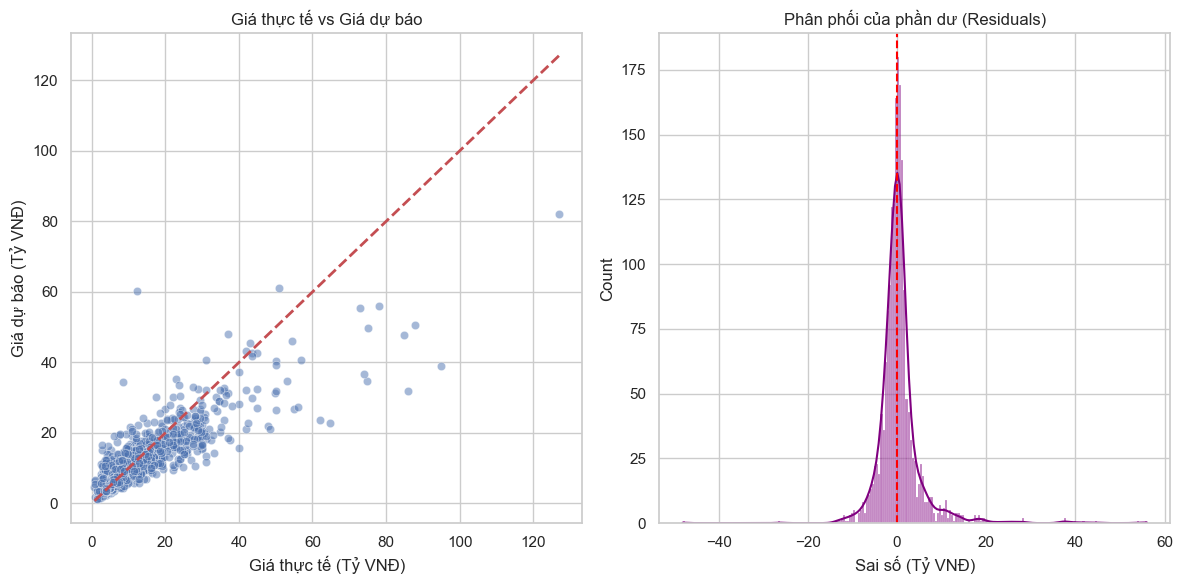

In [5]:
plt.figure(figsize=(12, 6))

# Tính toán phần dư (Residuals)
residuals = y_test_original - y_pred_original

# Vẽ biểu đồ Scatter giữa giá thực tế và giá dự báo
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.title("Giá thực tế vs Giá dự báo")
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự báo (Tỷ VNĐ)")

# Vẽ biểu đồ phân phối của phần dư
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Phân phối của phần dư (Residuals)")
plt.xlabel("Sai số (Tỷ VNĐ)")

plt.tight_layout()
plt.show()

In [6]:
# In ra dòng để copy vào báo cáo (Đầy đủ 4 chỉ số theo yêu cầu)
print(f"Model: Log-Log Multiple Regression (Area_log, Floors, Bath, Location, Legal)")
print("-" * 80)
print(f"R2: {r2:.4f} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")

Model: Log-Log Multiple Regression (Area_log, Floors, Bath, Location, Legal)
--------------------------------------------------------------------------------
R2: 0.7286 | MAE: 2.8103 | MSE: 28.8385 | RMSE: 5.3701
